Saved annotated result to c:\Users\Utilisateur\Code\IAPR_gr69\project\rectangular_hough_output\L1000768_yellow_canny_b1_l40_h59_minlen120_rectangles.png
Found 4 rectangle candidates
#1: score=615.55, box=(x=475, y=418, w=92, h=136)
#2: score=599.76, box=(x=33, y=433, w=86, h=136)
#3: score=559.11, box=(x=453, y=266, w=91, h=136)
#4: score=556.31, box=(x=427, y=91, w=87, h=131)


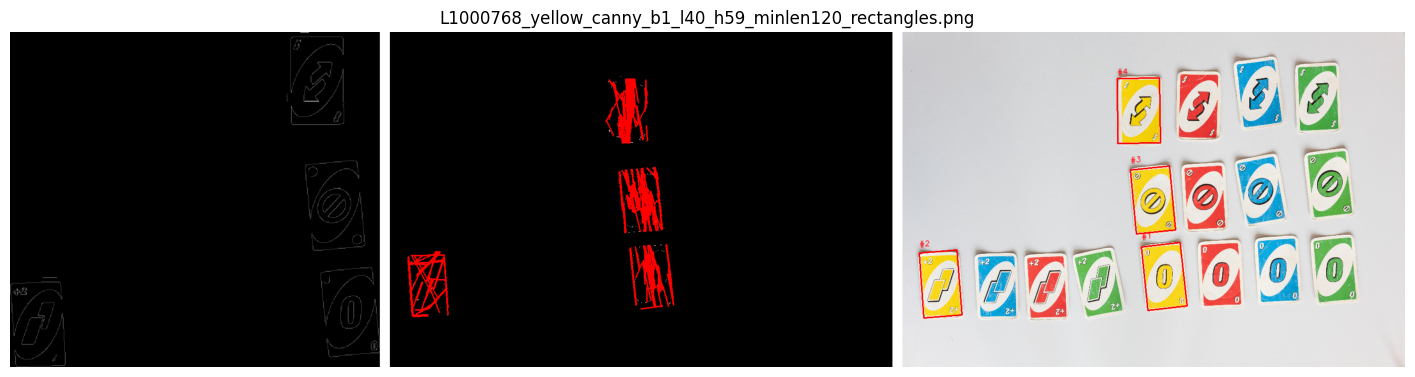

In [8]:
#!/usr/bin/env python3
"""
Detect rectangular candidates in a precomputed edge image using Hough line segments.

Edit `TARGET_EDGE_PATH` below to choose the edge image you want to analyze.
"""

from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


BASE_DIR = Path.cwd()

# Simple edit points for quick use.
TARGET_EDGE_PATH = BASE_DIR / "iapr-26-uno-vision-challenge" / "cards" / "L1000768_yellow_canny_b1_l40_h59_minlen120.png"
OVERLAY_IMAGE_PATH = BASE_DIR / "iapr-26-uno-vision-challenge" / "reference_images" / "L1000768.jpg"
TEMPLATE_EDGE_PATH = (
    BASE_DIR
    / "iapr-26-uno-vision-challenge"
    / "cards"
    / "L1000768_yellow_canny_b1_l40_h59_minlen120.png"
)
OUTPUT_DIR = BASE_DIR / "rectangular_hough_output"

SCALE = 0.25
def resolve_path(path: Path) -> Path:
    if path.is_absolute():
        return path
    return (BASE_DIR / path).resolve()
def crop_nonzero(image: np.ndarray) -> np.ndarray:
    ys, xs = np.where(image > 0)
    if len(xs) == 0 or len(ys) == 0:
        raise ValueError("The template edge image is empty.")
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return image[y0 : y1 + 1, x0 : x1 + 1]


def collect_rectangle_candidates(
    contours: list[np.ndarray],
) -> list[tuple[float, np.ndarray, tuple[int, int, int, int]]]:
    candidates: list[tuple[float, np.ndarray, tuple[int, int, int, int]]] = []

    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        if perimeter < 60:
            continue

        rect = cv2.minAreaRect(contour)
        (center_x, center_y), (width, height), _ = rect
        if width < 20 or height < 20:
            continue

        long_side = max(width, height)
        short_side = min(width, height)
        if short_side == 0:
            continue

        area = cv2.contourArea(contour)
        rect_area = width * height
        fill_ratio = area / rect_area if rect_area > 0 else 0.0
        aspect_ratio = long_side / short_side

        if fill_ratio < 0.2 or aspect_ratio > 6.0:
            continue

        score = perimeter * fill_ratio * min(aspect_ratio, 3.0)
        box = cv2.boxPoints(rect).astype(np.int32).reshape(-1, 1, 2)
        x, y, w, h = cv2.boundingRect(box)
        box_area = w * h
        score *= rect_area / box_area if box_area > 0 else 1.0
        candidates.append((score, box, (x, y, w, h)))

    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates


def detect_rectangles(
    template_edges: np.ndarray,
    target_edges: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, list[tuple[float, np.ndarray, tuple[int, int, int, int]]]]:
    template_edges = crop_nonzero(template_edges)
    template_small = cv2.resize(template_edges, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_AREA)
    target_small = cv2.resize(target_edges, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_NEAREST)
    target_edges_small = cv2.resize(
        target_small,
        (target_small.shape[1], target_small.shape[0]),
        interpolation=cv2.INTER_NEAREST,
    )

    line_canvas = cv2.cvtColor(target_edges_small, cv2.COLOR_GRAY2RGB)
    prepped_edges = cv2.dilate(
        target_edges_small,
        cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
        iterations=1,
    )
    line_mask = np.zeros_like(target_edges_small)

    lines = cv2.HoughLinesP(
        prepped_edges,
        rho=1,
        theta=np.pi / 180,
        threshold=20,
        minLineLength=20,
        maxLineGap=25,
    )
    if lines is None:
        print("No Hough lines were detected, falling back to the edge map directly.")
        line_mask = prepped_edges.copy()
    else:
        for line in lines[:, 0]:
            x1, y1, x2, y2 = line
            cv2.line(line_canvas, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.line(line_mask, (x1, y1), (x2, y2), 255, 2)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    rect_mask = cv2.morphologyEx(line_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(rect_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = collect_rectangle_candidates(contours)

    if not candidates:
        fallback_contours, _ = cv2.findContours(
            target_edges_small,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )
        candidates = collect_rectangle_candidates(fallback_contours)

    if not candidates:
        dilated = cv2.dilate(
            target_edges_small,
            cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9)),
            iterations=2,
        )
        component_contours, _ = cv2.findContours(
            dilated,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE,
        )
        candidates = collect_rectangle_candidates(component_contours)

    if not candidates:
        raise RuntimeError("No rectangular candidates were found.")

    candidates.sort(key=lambda item: item[0], reverse=True)
    return template_small, line_canvas, candidates


def save_outputs(
    output_dir: Path,
    edge_path: Path,
    overlay_path: Path,
    template_small: np.ndarray,
    line_canvas: np.ndarray,
    target_edges: np.ndarray,
    candidates: list[tuple[float, np.ndarray, tuple[int, int, int, int]]],
) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)

    overlay_image = cv2.imread(str(overlay_path), cv2.IMREAD_UNCHANGED)
    if overlay_image is None:
        raise FileNotFoundError(f"Could not load overlay image: {overlay_path}")

    overlay_small = cv2.resize(overlay_image, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_NEAREST)
    if overlay_small.ndim == 2:
        result_rgb = cv2.cvtColor(overlay_small, cv2.COLOR_GRAY2RGB)
    else:
        result_rgb = cv2.cvtColor(overlay_small, cv2.COLOR_BGR2RGB)

    top_k = min(10, len(candidates))
    for rank, (_, approx, (x, y, _, _)) in enumerate(candidates[:top_k], start=1):
        cv2.polylines(result_rgb, [approx], True, (255, 0, 0), 2)
        cv2.putText(
            result_rgb,
            f"#{rank}",
            (x, max(20, y - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1,
            cv2.LINE_AA,
        )

    template_rgb = cv2.cvtColor(template_small, cv2.COLOR_GRAY2RGB)
    target_height = result_rgb.shape[0]

    def fit_height(image: np.ndarray, height: int) -> np.ndarray:
        scale = height / image.shape[0]
        width = max(1, int(round(image.shape[1] * scale)))
        return cv2.resize(image, (width, height), interpolation=cv2.INTER_NEAREST)

    template_rgb = fit_height(template_rgb, target_height)
    line_canvas = fit_height(line_canvas, target_height)

    spacer = np.full((target_height, 20, 3), 255, dtype=np.uint8)
    combined = np.hstack([template_rgb, spacer, line_canvas, spacer, result_rgb])

    output_path = output_dir / f"{edge_path.stem}_rectangles.png"
    if not cv2.imwrite(str(output_path), cv2.cvtColor(combined, cv2.COLOR_RGB2BGR)):
        raise ValueError(f"Could not write result image: {output_path}")

    print(f"Saved annotated result to {output_path}")
    print(f"Found {len(candidates)} rectangle candidates")
    for rank, (score, _, (x, y, w, h)) in enumerate(candidates[:top_k], start=1):
        print(f"#{rank}: score={score:.2f}, box=(x={x}, y={y}, w={w}, h={h})")


edge_path = resolve_path(TARGET_EDGE_PATH)
overlay_path = resolve_path(OVERLAY_IMAGE_PATH)
template_path = resolve_path(TEMPLATE_EDGE_PATH)
output_dir = resolve_path(OUTPUT_DIR)

template_edges = cv2.imread(str(template_path), cv2.IMREAD_GRAYSCALE)
if template_edges is None:
    raise FileNotFoundError(f"Could not load template edge image: {template_path}")

target_edges = cv2.imread(str(edge_path), cv2.IMREAD_GRAYSCALE)
if target_edges is None:
    raise FileNotFoundError(f"Could not load target edge image: {edge_path}")

template_small, line_canvas, candidates = detect_rectangles(template_edges, target_edges)
save_outputs(output_dir, edge_path, overlay_path, template_small, line_canvas, target_edges, candidates)

result_path = output_dir / f"{edge_path.stem}_rectangles.png"
result_bgr = cv2.imread(str(result_path))
if result_bgr is not None:
    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(result_path.name)
    plt.show()
